# IMPORT

In [321]:
import pandas as pd
import numpy as np
from numpy import int64
import scipy.stats as stats
import seaborn as sns
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
import os
import sys
# Lấy thư mục hiện hành của Jupyter Notebook
current_dir = os.getcwd()
# Lên 3 cấp để chỉ định thư mục gốc của dự án (chứa thư mục 'src')
project_root = os.path.abspath(os.path.join(current_dir, '..', '..', '..'))
# Thêm thư mục project_root vào sys.path để có thể Import các module từ src
if project_root not in sys.path:
    sys.path.append(project_root)
# Import data_loader (Tệp thư viện nằm tại src/services/data_loader.py)
from src.services import data_loader
from src.core import math_engines


#LOAD DATA

In [322]:
nlg = data_loader.load_stocks(['NLG'])
nlg = pd.DataFrame(nlg['NLG'])
nlg.time = pd.to_datetime(nlg.time)
nlg.set_index('time', inplace=True)
nlg

Bắt đầu đọc 1 file song song...


,open,high,low,close,volume
time,,,,,
2023-09-11 09:15:00,35.32,35.41,35.32,35.41,26700
2023-09-11 09:16:00,35.41,35.41,35.41,35.41,5500
2023-09-11 09:17:00,35.41,35.58,35.41,35.45,21600
2023-09-11 09:18:00,35.45,35.45,35.41,35.45,5200
2023-09-11 09:19:00,35.45,35.45,35.41,35.41,2800
...,...,...,...,...,...
2026-02-27 14:26:00,27.85,27.85,27.80,27.85,14200
2026-02-27 14:27:00,27.85,27.85,27.80,27.85,16600
2026-02-27 14:28:00,27.85,27.90,27.85,27.90,4000


<Axes: xlabel='time'>

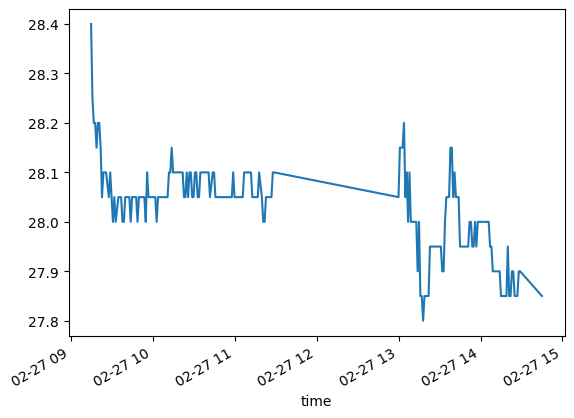

In [323]:
nlg_t = nlg[nlg.index.date == datetime(2026, 2, 27).date()]
nlg_t['close'].plot()

# TIME_BAR

<Axes: >

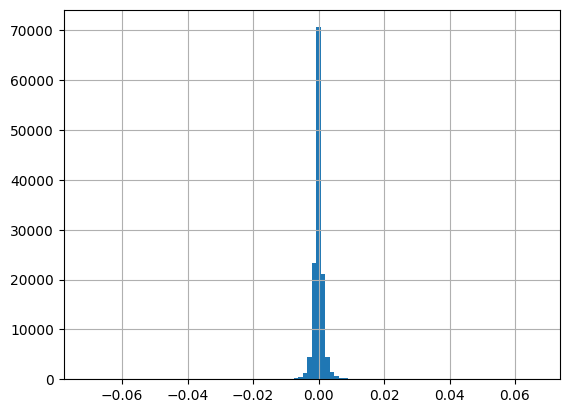

In [324]:
time_bar_return = np.log(nlg.close/nlg.close.shift(1))
time_bar_return.dropna(inplace=True)
time_bar_return.hist(bins=100)

# VOLUME_BAR

# DOLA_BAR

## standard dola bar

In [325]:
nlg['typical_price'] = (nlg.open+nlg.high+nlg.low+nlg.close)/3
nlg['dola_value'] = nlg.typical_price*nlg.volume
nlg.head(10)

,open,high,low,close,volume,typical_price,dola_value
time,,,,,,,
2023-09-11 09:15:00,35.32,35.41,35.32,35.41,26700,47.153333,1.258994e+06
2023-09-11 09:16:00,35.41,35.41,35.41,35.41,5500,47.213333,2.596733e+05
2023-09-11 09:17:00,35.41,35.58,35.41,35.45,21600,47.283333,1.021320e+06
2023-09-11 09:18:00,35.45,35.45,35.41,35.45,5200,47.253333,2.457173e+05
2023-09-11 09:19:00,35.45,35.45,35.41,35.41,2800,47.240000,1.322720e+05
2023-09-11 09:20:00,35.36,35.36,35.14,35.14,51800,47.000000,2.434600e+06
2023-09-11 09:21:00,35.14,35.14,35.14,35.14,300,46.853333,1.405600e+04
2023-09-11 09:22:00,35.14,35.14,35.14,35.14,21200,46.853333,9.932907e+05
2023-09-11 09:23:00,35.14,35.14,35.14,35.14,1000,46.853333,4.685333e+04


In [326]:
def generate_dynamic_dollar_bars(df, rolling_window=20, n_target=5):
    """
    Động cơ sinh Thanh Đô la (Dollar Bars) với ngưỡng Vt cập nhật động qua từng ngày.
    
    Yêu cầu đầu vào:
    - df: DataFrame chứa dữ liệu tick hoặc nến 1 phút. 
           Bắt buộc có DatetimeIndex. Các cột bắt buộc: 'price', 'volume', 'dola_value'.
    """
    print("Bắt đầu tiền xử lý: Tính toán Bảng tra cứu Vt...")
    
    # 1. Tạo chuỗi Tổng Đô la hàng ngày
    daily_dollar_volume = df['dola_value'].resample('D').sum()
    daily_dollar_volume = daily_dollar_volume[daily_dollar_volume > 0] # Lọc ngày nghỉ
    
    # 2. Xây dựng Từ điển Tra cứu Vt (Kiểu Nhảy Bậc - Stepped Window)
    vt_dict = {}
    unique_dates = np.unique(df.index.date)
    
    # Duyệt qua các ngày theo từng bước nhảy (step) bằng đúng rolling_window
    for i in range(0, len(unique_dates), rolling_window):
        # 1. Xác định block hiện tại và block tiếp theo
        current_block = unique_dates[i : i + rolling_window]
        next_block = unique_dates[i + rolling_window : i + 2 * rolling_window]
        
        # 2. Tính Vt dựa trên dữ liệu tổng hợp của cả block hiện tại
        is_in_block = np.isin(daily_dollar_volume.index.date, current_block)
        block_data = daily_dollar_volume[is_in_block]

        
        if len(block_data) >= rolling_window:
            # Tính 1 mức Vt duy nhất cho cả giai đoạn sau
            calculated_vt = block_data.mean() / n_target
        else:
            calculated_vt = np.nan # Không đủ dữ liệu cho block này
            
        # 3. Áp dụng mức Vt vừa tính được cho TOÀN BỘ các ngày trong block tiếp theo
        for d in next_block:
            vt_dict[d] = calculated_vt
            
        # 4. Giai đoạn đầu tiên (i=0) thì block hiện tại sẽ không có Vt áp dụng (NaN)
        if i == 0:
            for d in current_block:
                if d not in vt_dict: vt_dict[d] = np.nan

    print("Hoàn tất Bảng tra cứu. Bắt đầu lấy mẫu Dollar Bars...")
    
    # 3. Khởi tạo các biến Trạng thái (State variables)
    bars = []
    cum_dollar = 0.0
    cum_volume = 0.0
    cum_ticks = 0
    high_price = -np.inf
    low_price = np.inf
    open_price = None
    open_time = None

    # Lặp qua từng dòng dữ liệu bằng itertuples (Tốc độ cao)
    for row in df.itertuples():
        current_datetime = row.Index
        current_date = current_datetime.date()
        
        # Lấy ngưỡng Vt của ngày hôm nay từ Từ điển
        current_vt = vt_dict.get(current_date, np.nan)
        
        # Nếu đang ở giai đoạn mồi (chưa có Vt), bỏ qua tick này
        if pd.isna(current_vt):
            continue
            
        # Trích xuất dữ liệu của tick hiện tại
        price = row.typical_price
        volume = row.volume
        dollar_val = row.dola_value
        
        # Khởi tạo giá Mở cửa cho thanh mới
        if open_price is None:
            open_price = price
            open_time = current_datetime
            
        # Cập nhật các biến tích lũy
        cum_dollar += dollar_val
        cum_volume += volume
        cum_ticks += 1
        if price > high_price: high_price = price
        if price < low_price: low_price = price
            
        # 4. KIỂM TRA NGƯỠNG (THRESHOLD CHECK)
        if cum_dollar >= current_vt:
            # Sinh ra một Thanh Đô la mới
            bars.append({
                'open_time': open_time,
                'close_time': current_datetime, # Thời điểm đóng thanh
                'open': open_price,
                'high': high_price,
                'low': low_price,
                'close': price,
                'volume': cum_volume,
                'dola_value': cum_dollar,
                'tick_count': cum_ticks,
                'vt_threshold': current_vt # Lưu lại ngưỡng để kiểm tra sau này
            })
            
            # 5. Reset Trạng thái (Khớp với nguyên lý tích lũy liên tục)
            # Trừ đi phần đã đóng gói, giữ lại phần dư thừa (Overshoot) cho thanh sau
            cum_dollar = cum_dollar - current_vt 
            
            # Reset các biến khác
            cum_volume = 0.0
            cum_ticks = 0
            high_price = -np.inf
            low_price = np.inf
            open_price = None 
            # (Nếu phần dư cum_dollar > current_vt, vòng lặp sau sẽ đóng thanh ngay lập tức)

    # Chuyển đổi danh sách thành DataFrame
    dollar_bars_df = pd.DataFrame(bars)
    if not dollar_bars_df.empty:
        dollar_bars_df.set_index('close_time', inplace=True)
        
    return dollar_bars_df

In [327]:
df = generate_dynamic_dollar_bars(nlg, rolling_window=20, n_target=20)
df.head(10)

Bắt đầu tiền xử lý: Tính toán Bảng tra cứu Vt...
Hoàn tất Bảng tra cứu. Bắt đầu lấy mẫu Dollar Bars...


,open_time,open,high,low,close,volume,dola_value,tick_count,vt_threshold
close_time,,,,,,,,,
2023-10-09 09:33:00,2023-10-09 09:15:00,38.353333,39.333333,38.353333,39.333333,132100.0,5.133471e+06,17,5.101282e+06
2023-10-09 10:27:00,2023-10-09 09:34:00,39.333333,39.333333,38.800000,39.106667,132500.0,5.200553e+06,44,5.101282e+06
2023-10-09 11:28:00,2023-10-09 10:28:00,39.106667,39.160000,38.866667,39.133333,130700.0,5.199270e+06,51,5.101282e+06
2023-10-09 13:24:00,2023-10-09 11:29:00,39.106667,39.393333,38.986667,39.393333,187200.0,7.444724e+06,23,5.101282e+06
2023-10-09 13:41:00,2023-10-09 13:25:00,39.470000,39.470000,39.133333,39.133333,72600.0,5.194736e+06,10,5.101282e+06
2023-10-09 14:15:00,2023-10-09 13:42:00,39.133333,39.306667,38.920000,39.306667,153100.0,6.082864e+06,28,5.101282e+06
2023-10-09 14:18:00,2023-10-09 14:16:00,39.366667,39.513333,39.366667,39.513333,107800.0,5.231712e+06,3,5.101282e+06
2023-10-09 14:45:00,2023-10-09 14:19:00,39.606667,39.933333,39.520000,39.933333,200600.0,8.110714e+06,12,5.101282e+06
2023-10-10 09:23:00,2023-10-10 09:15:00,40.413333,40.413333,40.173333,40.263333,58100.0,5.353073e+06,8,5.101282e+06


--- BÁO CÁO THỐNG KÊ: Dollar Bars ---
Số lượng quan sát (N): 12976
Độ lệch (Skewness)  : -0.1504 (Gần 0 là tốt)
Độ nhọn (Kurtosis)   : 22.1363 (Gần 0 là tốt. >0 là đuôi béo)
Jarque-Bera Stat     : 264984.17
P-value              : 0.000000e+00


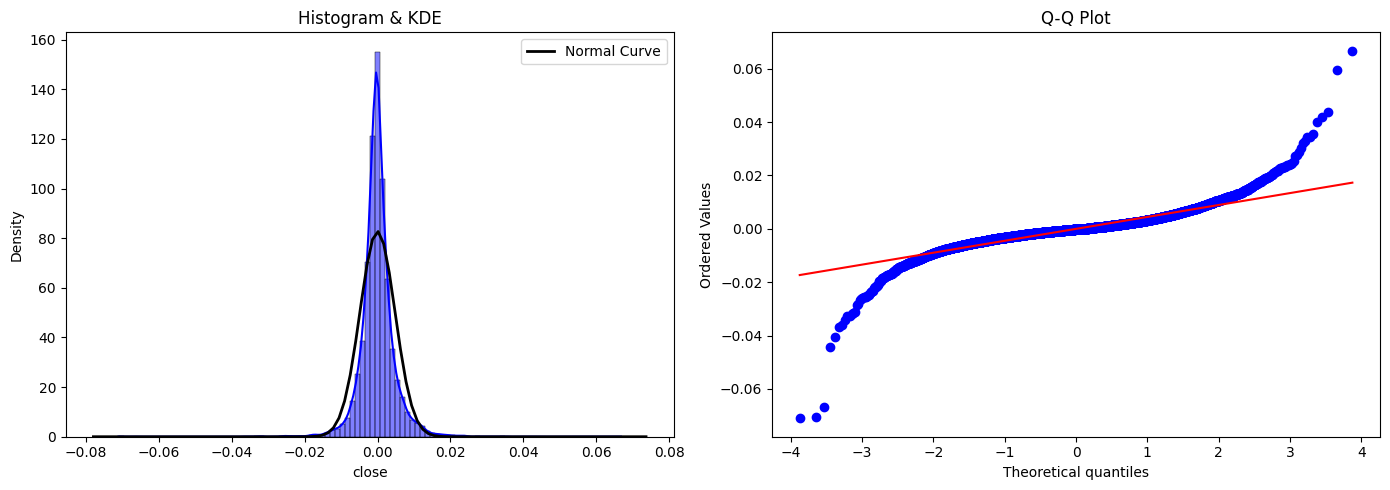

In [328]:
def test_normality(bars_df, title="Dollar Bars Normality Test"):
    """
    Thực hiện kiểm định tính chuẩn toàn diện trên chuỗi Lợi suất Logarit.
    """
    # 1. Tính Log Returns
    # Thay 'close' bằng tên cột giá đóng cửa thực tế trong DataFrame của Anh
    returns = np.log(bars_df['close'] / bars_df['close'].shift(1)).dropna()
    
    # 2. Tính toán các Moment Thống kê
    skewness = stats.skew(returns)
    kurtosis = stats.kurtosis(returns) # Hàm này trả về Excess Kurtosis (Độ nhọn vượt trội so với phân phối chuẩn có mức = 0)
    
    # 3. Kiểm định Jarque-Bera
    jb_stat, p_value = stats.jarque_bera(returns)
    
    # 4. In Báo cáo
    print(f"--- BÁO CÁO THỐNG KÊ: {title} ---")
    print(f"Số lượng quan sát (N): {len(returns)}")
    print(f"Độ lệch (Skewness)  : {skewness:.4f} (Gần 0 là tốt)")
    print(f"Độ nhọn (Kurtosis)   : {kurtosis:.4f} (Gần 0 là tốt. >0 là đuôi béo)")
    print(f"Jarque-Bera Stat     : {jb_stat:.2f}")
    print(f"P-value              : {p_value:.6e}")
    
    # 5. Vẽ đồ thị Trực quan hóa
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Đồ thị Histogram & KDE so với Phân phối chuẩn
    sns.histplot(returns, kde=True, stat='density', ax=axes[0], color='blue', bins=100)
    xmin, xmax = axes[0].get_xlim()
    x = np.linspace(xmin, xmax, 100)
    p = stats.norm.pdf(x, np.mean(returns), np.std(returns))
    axes[0].plot(x, p, 'k', linewidth=2, label='Normal Curve')
    axes[0].set_title('Histogram & KDE')
    axes[0].legend()
    
    # Biểu đồ Q-Q Plot
    stats.probplot(returns, dist="norm", plot=axes[1])
    axes[1].set_title('Q-Q Plot')
    
    plt.tight_layout()
    plt.show()


test_normality(df, "Dollar Bars")

Tổng số ticks: 129107
Số lượng ticks mỗi nến: 9
Số lượng Time Bars tạo ra: 12976 (Khớp mục tiêu!)
--- BÁO CÁO THỐNG KÊ: Dollar Bars Normality Test ---
Số lượng quan sát (N): 12975
Độ lệch (Skewness)  : -0.1678 (Gần 0 là tốt)
Độ nhọn (Kurtosis)   : 24.1392 (Gần 0 là tốt. >0 là đuôi béo)
Jarque-Bera Stat     : 315084.07
P-value              : 0.000000e+00


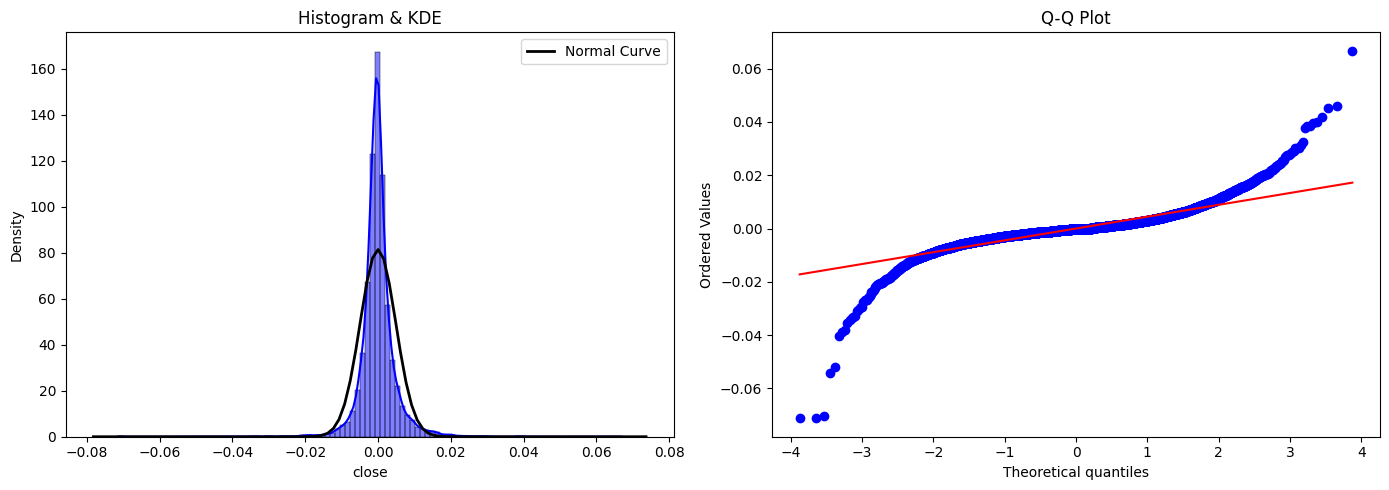

In [330]:
def generate_equivalent_time_bars(nlg, target_bars=3078):
    """
    Tạo Time Bars dựa trên số lượng ticks cố định cho mỗi nến.
    Đây là cách duy nhất để có số lượng mẫu chính xác tuyệt đối.
    """
    total_ticks = len(nlg)
    
    # 1. Tính toán mỗi nến chứa bao nhiêu tick (dòng dữ liệu)
    ticks_per_bar = total_ticks // target_bars
    
    print(f"Tổng số ticks: {total_ticks}")
    print(f"Số lượng ticks mỗi nến: {ticks_per_bar}")
    
    # 2. Gán ID nhóm cho từng dòng dữ liệu
    # Ví dụ: 0,0,0... (ticks_per_bar lần), rồi 1,1,1...
    nlg = nlg.copy()
    nlg['group_id'] = np.arange(total_ticks) // ticks_per_bar
    
    # 3. Gom nhóm (Groupby) thay vì Resample
    time_bars = nlg.groupby('group_id').agg({
        'typical_price': ['first', 'max', 'min', 'last'],
        'volume': 'sum',
        'dola_value': 'sum'
    })
    
    # Đặt lại Index là thời điểm cuối cùng của mỗi nhóm (để đồng bộ với Dollar Bars)
    time_bars.index = nlg.groupby('group_id').apply(lambda x: x.index[-1])
    
    # 4. Làm phẳng cột và dọn dẹp
    time_bars.columns = ['open', 'high', 'low', 'close', 'volume', 'dola_value']
    time_bars.index.name = 'close_time'
    
    # Giới hạn số lượng đúng bằng target_bars (bỏ phần dư ở cuối nếu có)
    time_bars = time_bars.head(target_bars)
    
    print(f"Số lượng Time Bars tạo ra: {len(time_bars)} (Khớp mục tiêu!)")
    
    return time_bars
    
# Chạy thực thi
df_time_bars = generate_equivalent_time_bars(nlg, target_bars=12976)
test_normality(df_time_bars)